<a href="https://colab.research.google.com/github/Kaustav2706/FinVault/blob/main/AI_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv('Dataset.csv', engine='python', on_bad_lines='skip')
print(df.head())

  Location  IMIPENEM  CEFTAZIDIME  GENTAMICIN  AUGMENTIN  CIPROFLOXACIN
0    IFE-T        25           20          20         15             28
1    IFE-T        25           25          20         20             30
2    IFE-T        30           10          20         20             25
3    IFE-T        25           20          20         25             28
4    IFE-T        25            7          20         20             22


In [3]:
import pandas as pd

df = pd.read_csv('Dataset.csv', engine='python')
df.head()

,Location,IMIPENEM,CEFTAZIDIME,GENTAMICIN,AUGMENTIN,CIPROFLOXACIN
0,IFE-T,25,20,20,15,28
1,IFE-T,25,25,20,20,30
2,IFE-T,30,10,20,20,25
3,IFE-T,25,20,20,25,28
4,IFE-T,25,7,20,20,22


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Location', axis=1)
y = df['Location']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [6]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.34545454545454546


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('Location', axis=1)
y = df['Location']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [9]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.3090909090909091


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Location'])

In [11]:
X = df.drop('Location', axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.2545454545454545


In [13]:
import pandas as pd
print(pd.Series(y).value_counts())

5     31
8     27
4     24
11    23
10    23
9     23
7     22
0     21
1     21
2     21
6     20
3     18
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Mean Accuracy:", scores.mean())

Mean Accuracy: 0.25555555555555554


In [15]:
import numpy as np

# Create resistance score
df['ResistanceScore'] = df[['IMIPENEM','CEFTAZIDIME','GENTAMICIN','AUGMENTIN','CIPROFLOXACIN']].mean(axis=1)

# Convert to categories
df['ResistanceLevel'] = pd.cut(
    df['ResistanceScore'],
    bins=[0, 15, 25, 40],
    labels=['Low', 'Medium', 'High']
)

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

le = LabelEncoder()
y = le.fit_transform(df['ResistanceLevel'])

X = df[['IMIPENEM','CEFTAZIDIME','GENTAMICIN','AUGMENTIN','CIPROFLOXACIN']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [17]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.7818181818181819


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.8545454545454545


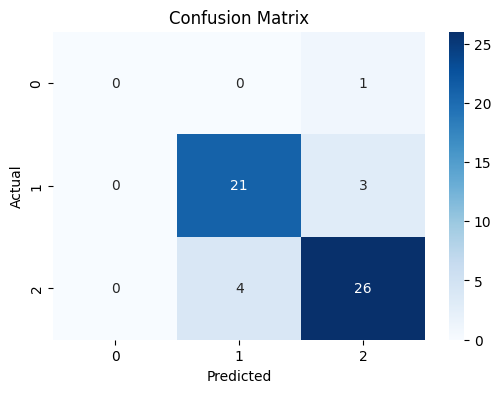

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

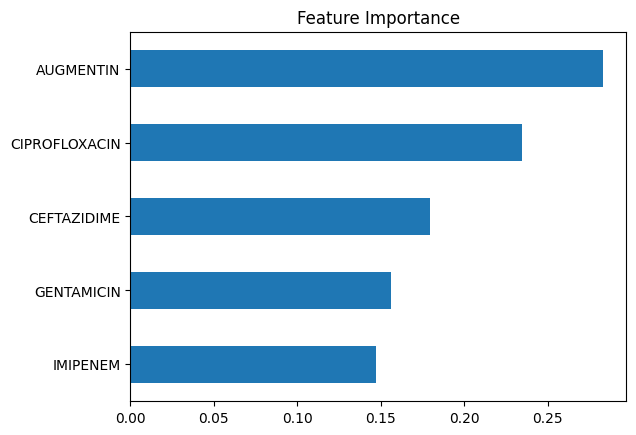

In [20]:
import pandas as pd

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

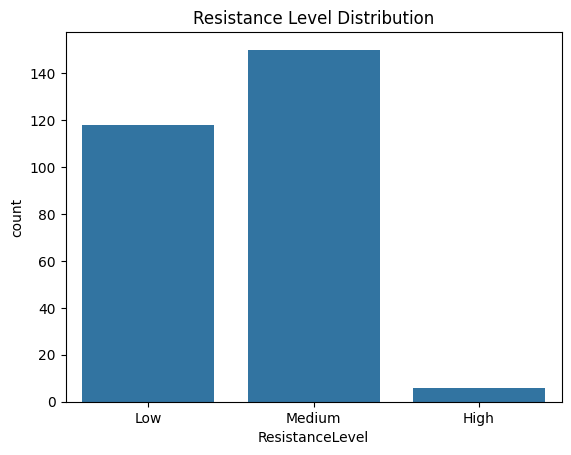

In [21]:
sns.countplot(x=df['ResistanceLevel'])
plt.title("Resistance Level Distribution")
plt.show()

In [22]:
sample = [[25, 20, 20, 15, 28]]

prediction = model.predict(sample)

print("Predicted Resistance Level:", prediction)

Predicted Resistance Level: [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
import joblib
joblib.dump(model, 'resistance_model.pkl')

['resistance_model.pkl']

In [24]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("Final Accuracy:", round(acc * 100, 2), "%")

Final Accuracy: 85.45 %


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.84      0.88      0.86        24
           2       0.87      0.87      0.87        30

    accuracy                           0.85        55
   macro avg       0.57      0.58      0.57        55
weighted avg       0.84      0.85      0.85        55



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-val Accuracy:", round(scores.mean() * 100, 2), "%")

Cross-val Accuracy: 90.13 %


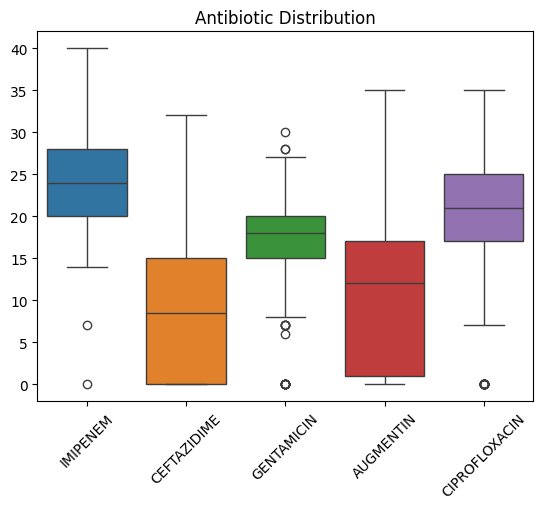

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['IMIPENEM','CEFTAZIDIME','GENTAMICIN','AUGMENTIN','CIPROFLOXACIN']])
plt.title("Antibiotic Distribution")
plt.xticks(rotation=45)
plt.show()

In [28]:
def decision_support(prediction_label):
    if prediction_label == "Low":
        return "Use standard antibiotics. Monitor patient."

    elif prediction_label == "Medium":
        return "Adjust dosage or consider combination therapy."

    elif prediction_label == "High":
        return "Avoid standard antibiotics. Use advanced/targeted therapy. Immediate attention required."

In [29]:
import pandas as pd

sample = pd.DataFrame([[25, 20, 20, 15, 28]], columns=X.columns)

prediction = model.predict(sample)
label = le.inverse_transform(prediction)[0]

decision = decision_support(label)

print("Predicted Resistance Level:", label)
print("Recommended Action:", decision)

Predicted Resistance Level: Medium
Recommended Action: Adjust dosage or consider combination therapy.


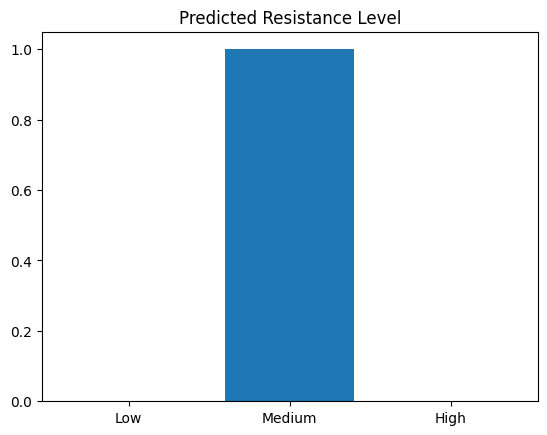

In [30]:
import matplotlib.pyplot as plt

labels = ['Low', 'Medium', 'High']
values = [0, 0, 0]

if label == 'Low':
    values[0] = 1
elif label == 'Medium':
    values[1] = 1
else:
    values[2] = 1

plt.bar(labels, values)
plt.title("Predicted Resistance Level")
plt.show()

In [31]:
probs = model.predict_proba(sample)

confidence = max(probs[0]) * 100

print("Confidence:", round(confidence, 2), "%")

Confidence: 99.51 %
